<a href="https://colab.research.google.com/github/Loicsav/SalasOrtegaConde/blob/main/Entornos_Complejos/DiferenciaTemporal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diferencias Temporales**

_Esto es un ejemplo de uso de Gymnasium e informe sobre un experimento de aprendizaje por refuerzo_

````
Luis D. Hernández.
<ldaniel at um.es>
````

Este notebook describe un experimento de aprendizaje por refuerzo utilizando el algoritmo de Monte Carlo con políticas epsilon-soft. El propósito de este análisis es entrenar un agente en un entorno de gym con el juego "FrozenLake", un entorno estándar en el que el agente debe aprender a moverse a través de un mapa en busca de una meta, evitando caer en agujeros. A continuación, se presenta una descripción de las diferentes partes del código y el proceso utilizado en el experimento.

🎯 **Ojo, el código debe modificarse para ser un auténtico Monte Carlo. Supongo que sabrás darte cuenta.**

## **1. Preparación del Entorno**

La preparación consta de las siguientes partes:
- **Instalación de Dependencias**: Se instalan las librerías necesarias para utilizar el entorno `gymnasium` para la simulación, con el objetivo de crear un ambiente controlado para que el agente pueda interactuar.
- **Importación de Librerías**: Se importan las bibliotecas necesarias como `numpy` para el manejo de matrices y `matplotlib` para la visualización de los resultados.

- **Importación del Entorno "FrozenLake"**:
Se cargan dos versiones del entorno "FrozenLake": una de 4x4 y otra de 8x8. Ambas versiones no son resbaladizas, lo que facilita la comprensión de los resultados, dado que el entorno resbaladizo podría dificultar la comprensión inicial del aprendizaje.

#### 3. **Funciones para Mostrar los Resultados**
   - Se define una función para graficar la proporción de recompensas obtenidas en cada episodio del entrenamiento. Esto ayuda a visualizar el progreso del agente en términos de su desempeño durante el entrenamiento.



##### **Código de la Instalación e Importación**
----

%%capture
#@title Instalamos gym
!pip install 'gym[box2d]==0.20.0'

## Instalación de algunos paquetes.
#!apt-get update
## Para usar gymnasium[box2d]
#!apt install swig
#!pip install gymnasium[box2d]


# Instalación de algunos paquetes.
!apt-get update

# Para visualizar en colab https://medium.com/@coldstart_coder/visually-rendering-python-gymnasium-in-jupyter-notebooks-4413e4087a0f
!apt-get install -y python-opengl ffmpeg
!apt-get install --upgrade cmake

# Para usar gymnasium[box2d]
!apt install swig xvfb
!pip install -U  pyvirtualdisplay

!pip install gymnasium gymnasium[box2d]

In [1]:
#@title Importamos librerias
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
import torch
import gc

from src.agents.AgenteDT_Sarsa import AgenteDT_Sarsa
from src.agents.AgenteDT_Double_QL import AgenteDT_Double_QL
from src.agents.AgenteDT_QL import AgenteDT_QL

from src.ploting import *

In [2]:
# Configuración del dispositivo (CPU o GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Liberación de memoria para evitar problemas de consumo en GPU
gc.collect() # Ejecuta el recolector de basura de Python
torch.cuda.empty_cache() # Vacía la caché de memoria en GPU

# Depuración de errores en CUDA
os.environ['CUDA_LAUNCH_BLOCKING'] = '1' # Muestra errores de CUDA en el punto exacto donde ocurren
# Configuración de la semilla para reproducibilidad
seed = 2024 # Se define una semilla fija

# Fijar la semilla en NumPy
np.random.seed(seed) # Para generar números aleatorios consistentes en NumPy
np.random.default_rng(seed) # Establece una instancia del generador de NumPy con la misma semilla

# Fijar la semilla en Python
os.environ['PYTHONHASHSEED'] = str(seed) # Evita variabilidad en hashing de Python

# Fijar la semilla en PyTorch
torch.manual_seed(seed) # Asegura resultados reproducibles en operaciones de PyTorch
if torch.cuda.is_available(): # Si hay GPU disponible
    torch.cuda.manual_seed(seed) # Fija la semilla para la GPU
    torch.backends.cudnn.deterministic = True # Hace las operaciones de CUDNN determinísticas
    torch.backends.cudnn.benchmark = False # Desactiva optimizaciones de CUDNN para evitar variabilidad

Usando dispositivo: cpu


In [3]:
#@title Importamos el lago helado
video_folder = "./videos"  # Asegúrate de que esta ruta coincide con la carpeta donde se guardan los videos
name = 'FrozenLake-v1'
render = "rgb_array"
env4 = gym.make(name, is_slippery=False, map_name="4x4", render_mode=render, max_episode_steps=500) # No resbaladizo para entender mejor los resultados.
env8 = gym.make(name, is_slippery=False, map_name="8x8", render_mode=render, max_episode_steps=500) # No resbaladizo para entender mejor los resultados.

## **2. Diseño del Agente**

El diseño del agente consta de dos partes: las políticas de toma de decisiones y el algoritmo de aprendizaje. En este cuaderno nos centraremos en algoritmos de **Diferencia Temporal (TD)**.

### **Aprendizaje por Diferencia Temporal (TD)**
El aprendizaje por Diferencia Temporal es un método central en el aprendizaje por refuerzo. Combina ideas de Monte Carlo y Programación Dinámica:
*   Al igual que **Monte Carlo**, los métodos TD aprenden directamente de la experiencia cruda sin un modelo de la dinámica del entorno.
*   Al igual que la **Programación Dinámica**, los métodos TD actualizan las estimaciones basándose en parte en otras estimaciones aprendidas, sin esperar al final del episodio (bootstrapping).

### **Políticas del Agente**
   - **Política epsilon-soft**: Se define una política donde todas las acciones tienen una probabilidad no nula de ser elegidas.
   - **Política epsilon-greedy**: Basada en la política epsilon-soft. El agente tiene una pequeña probabilidad $\epsilon$ de explorar (tomar una acción aleatoria) y una mayor probabilidad $1-\epsilon$ de explotar (tomar la acción que considera mejor). Esto permite equilibrar la exploración y la explotación.
   - **Política greedy**: Selecciona siempre la acción con el mayor valor estimado. Es la usada una vez que el agente "ha aprendido".

### **Algoritmos implementados**

#### **1. Sarsa (State-Action-Reward-State-Action)**
Sarsa es un algoritmo de control **On-Policy** (sobre la política). Aprende una estimación de la función de valor de acción $Q_{\pi}(s, a)$ para la política de comportamiento actual.

La regla de actualización para Sarsa es:
$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha [R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t)]$$

Esta actualización se realiza después de cada transición de un estado $S_t$, tomando una acción $A_t$, recibiendo una recompensa $R_{t+1}$ y llegando a un nuevo estado $S_{t+1}$ donde se selecciona la siguiente acción $A_{t+1}$.

#### **2. Q-Learning**
Q-Learning es un algoritmo de control **Off-Policy** (fuera de la política). Aprende directamente la función de valor de acción óptima $Q^*(s, a)$, independientemente de la política que se esté siguiendo (siempre que explore lo suficiente).

La regla de actualización para Q-Learning es:
$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha [R_{t+1} + \gamma \max_{a} Q(S_{t+1}, a) - Q(S_t, A_t)]$$

En este caso, el valor del siguiente estado se estima asumiendo que se tomará la mejor acción posible ($\max_a$), en lugar de la acción que realmente dicta la política actual.

#### **3. Double Q-Learning**
El algoritmo Double Q-Learning se introduce para resolver el **sesgo de maximización** inherente a Q-Learning, que tiende a sobreestimar los valores de acción debido al operador de máximo.

Para ello, utiliza dos estimaciones de valor independientes, $Q_1$ y $Q_2$. En cada paso, se selecciona aleatoriamente una para actualizarse utilizando la otra para estimar el valor:

Si se actualiza $Q_1$:
$$Q_1(S_t, A_t) \leftarrow Q_1(S_t, A_t) + \alpha [R_{t+1} + \gamma Q_2(S_{t+1}, \mathop{\mathrm{argmax}}_{a} Q_1(S_{t+1}, a)) - Q_1(S_t, A_t)]$$

Si se actualiza $Q_2$:
$$Q_2(S_t, A_t) \leftarrow Q_2(S_t, A_t) + \alpha [R_{t+1} + \gamma Q_1(S_{t+1}, \mathop{\mathrm{argmax}}_{a} Q_2(S_{t+1}, a)) - Q_2(S_t, A_t)]$$

#### **Código de las políticas y algoritmo MC**
----------------

In [4]:
#@title Algoritmo de Iteración de Valor versión MC con Políticas epsilon-soft

def diferencia_temporal(env, agente, num_episodes=5000):
    stats = 0.0
    list_stats = []
    all_episode_lengths = [] 
    step_display = max(1, num_episodes // 10)

    for t in tqdm(range(num_episodes)):
        state, info = env.reset(seed=seed)
        done = False
        episode = []
        result_sum  = 0.0
        action = agente.get_action(state, t)
        while not done:
            new_state, reward, terminated, truncated, info = env.step(action)
            new_action = agente.get_action(new_state, t)

            done = terminated or truncated
            
            # Guardamos el estado, la acción y la recompensa INMEDIATA
            episode.append((state, action, reward))
            agente.update(state, action, reward, new_state, new_action, done)
            result_sum += reward
            state = new_state
            action = new_action

        # Guardamos datos sobre la evolución
        stats += result_sum
        list_stats.append(stats / (t + 1))
        all_episode_lengths.append(len(episode))

        if t % step_display == 0 and t != 0:
            print(f"Episode: {t}, Avg Return: {stats/t:.2f}, Epsilon: {agente.epsilon:.3f}, Alpha: {agente.alpha:.3f}")

    return list_stats, all_episode_lengths


## **3. Experimentación**

En esta sección realizaremos una comparativa exhaustiva de los algoritmos de Diferencia Temporal (Sarsa, Q-Learning y Double Q-Learning) en los entornos de FrozenLake.

### **Metodología Experimental**
Para cada algoritmo y entorno (4x4 y 8x8 sin resbalar), seguiremos el siguiente procedimiento:

1.  **Entrenamiento**:
    -   Se ejecutará el algoritmo durante un número fijo de episodios (10,000 para 4x4 y 30,000 para 8x8).
    -   Utilizaremos una política **epsilon-greedy** con decaimiento. Partiremos de un $\epsilon=0.4$ que disminuirá progresivamente para favorecer la explotación conforme avanza el aprendizaje.
    -   El factor de descuento $\gamma$ se fija en 0.9.

2.  **Visualización y Análisis de Resultados**:
    -   **Proporción de Recompensas**: Gráfica de la media móvil de recompensas obtenidas ($f(t)=\frac{\sum_{i=1}^t R_i}{t}$). Nos indicará la estabilidad y velocidad de convergencia del aprendizaje.
    -   **Longitud del Episodio**: Gráfica del número de pasos por episodio. Un descenso indica que el agente aprende a llegar a la meta más rápido.
    -   **Mapa de Valores Q**: Visualización térmica de la tabla Q final. Permite interpretar qué estados considera valiosos el agente y qué acciones prefiere en cada uno (política derivada).
    -   **Video de demostración**: Generación de un video de un episodio usando la política aprendida para verificar cualitativamente el comportamiento del agente.


### **3.1 Repressentaciones Gráficas**

Para comprobar el aprendizaje se mostrará la función $f(t)=\frac{\sum_{i=1}^t R_i}{t}$ para $t=1,2,\ldots, NumeroEpisodios$. La justificación es la siguiente. Como sabemmos que el retorno en el estados inicial 1 (pues no hay descuento) o 9, si se divide por el número de episodios ejecutados se calcular el porcentaje de recompensas positivas obtenidas. Dicho de otra forma, nos dirá el porcentaje de veces que el agente ha llegado al estado terminal.


### **3.2 Experimentación en el escenario 4x4**



   - Se realizan 5000 epsisodios y se actualizan los valores Q (valor de acción) basándose en las recompensas obtenidas durante cada episodio completo (e.d. aplicamos Monte Carlo) Se apica una política $\epsilon$ greedy sobre una política $\epsilon$ soft con un valor $\epsilon$ constante




#### **3.2.1 Algoritmo de SARSA**

In [6]:
# @title Aprendizaje
agente_DT_Sarsa_V4 = AgenteDT_Sarsa(env4, seed, discount_factor=0.9, epsilon=0.4, decay=True, num_episodes=10000, decay_rate=1000.0)
list_stats, all_episode_lengths = diferencia_temporal(env4, agente=agente_DT_Sarsa_V4, num_episodes=10000)

 11%|█         | 1070/10000 [00:01<00:09, 920.73it/s]

Episode: 1000, Avg Return: 0.02, Epsilon: 0.999, Alpha: 0.885


 22%|██▏       | 2228/10000 [00:02<00:06, 1224.23it/s]

Episode: 2000, Avg Return: 0.05, Epsilon: 0.500, Alpha: 1.000


 34%|███▎      | 3373/10000 [00:02<00:03, 1873.99it/s]

...

 83%|████████▎ | 8336/10000 [00:04<00:00, 2506.31it/s]

Episode: 8000, Avg Return: 0.56, Epsilon: 0.125, Alpha: 0.022


 95%|█████████▍| 9483/10000 [00:05<00:00, 2720.85it/s]

Episode: 9000, Avg Return: 0.59, Epsilon: 0.111, Alpha: 0.019


100%|██████████| 10000/10000 [00:05<00:00, 1851.88it/s]


Mostramos plots

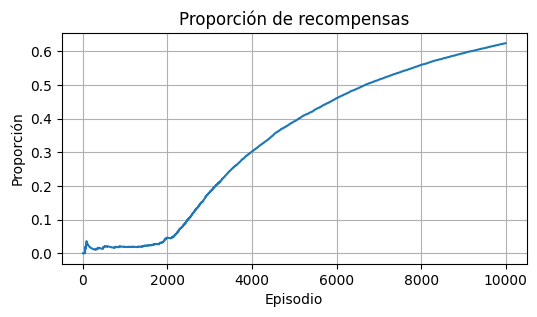

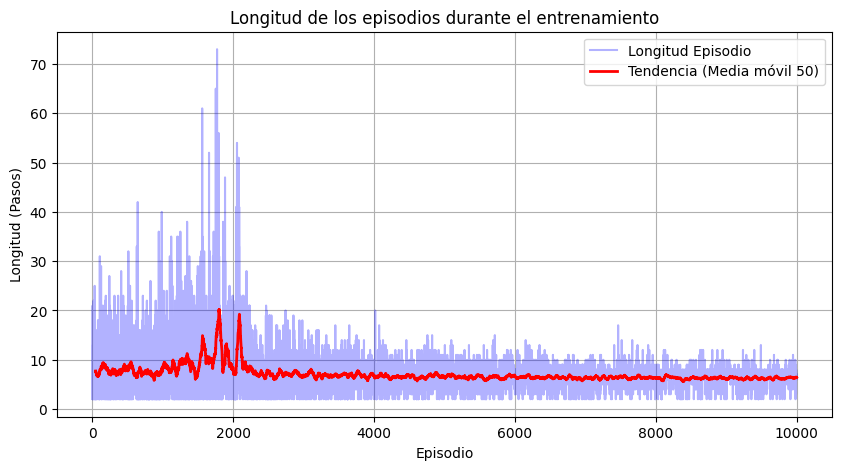

Máxima proporcion: 0.6244


In [7]:
#@title Proporción de aciertos por número de episodios

plot(list_stats)
plot_lengths(all_episode_lengths)
print(f"Máxima proporcion: {list_stats[-1]}")

Mostramos escenario

c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\.venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


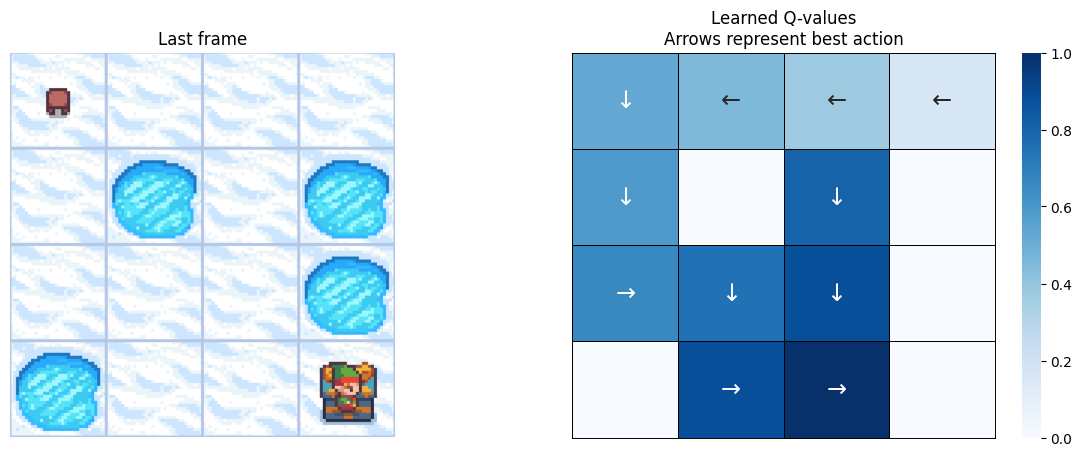

In [8]:
plot_q_values_map(agente_DT_Sarsa_V4.Q, env4, 4)

Mostramos video

In [9]:
generar_video(env4, agente_DT_Sarsa_V4.Q, video_folder=video_folder, num_episodes=1, seed=seed)
mostrar_video(get_latest_episode_video_file(video_folder))

c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\.venv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\Entornos_Complejos\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Grabación de episodios completada. Vídeos guardados en la carpeta './videos'


#### **3.2.2 Algoritmo de Q-Learning**

Ahora vamos a realizar el entrenamiento utilizando el algoritmo de **Q-Learning**. Para ello, se han empleado los siguientes parámetros:

- **Factor de descuento (alpha)**: 0.9
- **Epsilon Inicial**: 1.0
- **Epsilon Decay**: Activado ($\epsilon = \min(1.0, \frac{\text{decay\_rate}}{t+1})$)
- **Ratio de decay**: Tendremos tres ejecuciones para comparar cómo afecta la velocidad de decaimiento:
    - ``100``: Decaimiento rápido (menos exploración).
    - ``500``: Decaimiento medio.
    - ``1000``: Decaimiento lento (más exploración por más tiempo).

In [ ]:
# @title Aprendizaje
print("Decaimiento 100")
agente_DT_QL_V4_100 = AgenteDT_QL(env4, seed, discount_factor=0.9, epsilon=0.4, decay=True, num_episodes=10000, decay_rate=100.0)
list_stats_ql_100, all_episode_lengths_ql_100 = diferencia_temporal(env4, agente=agente_DT_QL_V4_100, num_episodes=10000)

print("Decaimiento 500")
agente_DT_QL_V4_500 = AgenteDT_QL(env4, seed, discount_factor=0.9, epsilon=0.4, decay=True, num_episodes=10000, decay_rate=500.0)
list_stats_ql_500, all_episode_lengths_ql_500 = diferencia_temporal(env4, agente=agente_DT_QL_V4_500, num_episodes=10000)

print("Decaimiento 1000")
agente_DT_QL_V4_1000 = AgenteDT_QL(env4, seed, discount_factor=0.9, epsilon=0.4, decay=True, num_episodes=10000, decay_rate=1000.0)
list_stats_ql_1000, all_episode_lengths_ql_1000 = diferencia_temporal(env4, agente=agente_DT_QL_V4_1000, num_episodes=10000)

 12%|█▏        | 1159/10000 [00:01<00:10, 847.84it/s]

Episode: 1000, Avg Return: 0.66, Epsilon: 0.100, Alpha: 0.151


 22%|██▏       | 2188/10000 [00:02<00:08, 907.28it/s]

Episode: 2000, Avg Return: 0.79, Epsilon: 0.050, Alpha: 0.063


 31%|███       | 3119/10000 [00:03<00:07, 885.78it/s]

...

 81%|████████▏ | 8137/10000 [00:09<00:01, 957.29it/s]

Episode: 8000, Avg Return: 0.58, Epsilon: 0.125, Alpha: 0.021


 91%|█████████ | 9112/10000 [00:10<00:00, 952.68it/s]

Episode: 9000, Avg Return: 0.62, Epsilon: 0.111, Alpha: 0.018


100%|██████████| 10000/10000 [00:11<00:00, 872.67it/s]


Tras realizar el entrenamiento con los tres valores de decaimiento, obtenemos estos entrenamientos.
* **Decaimiento 100**: Para la primera versión con decaimiento 100, vemos que aprende muy rápido ese camino solución al tener un valor de return medio de 0.66 desde el episodio 1000, llegando a 0.94 al final del entrenamiento. Esto se debe a su bajo epsilon durante los episodios, haciendo que explotase ese camino.
* **Decaimiento 500**: Para la segunda versión, vemos que ya empieza a tardar más en aprender el camino solución al querer explorar más respecto al anterior, teniendo que necesitar 5000 episodios para llegar a un return medio de 0.64, terminado con 0.77.
* **Decaimiento 1000**: Finalmente, para la tercera versión, es la que más tarda en entrenar, terminando con un return de 0.62.

Esto nos demuestra que hacer que el epsilon decrezca más rápido repercute en una explotación más rápida.

Ahora vamos a ver su evolución gráficamente en la proporcion de la recompensa promedia y la media de longitud de episodios hasta llegar al final. 

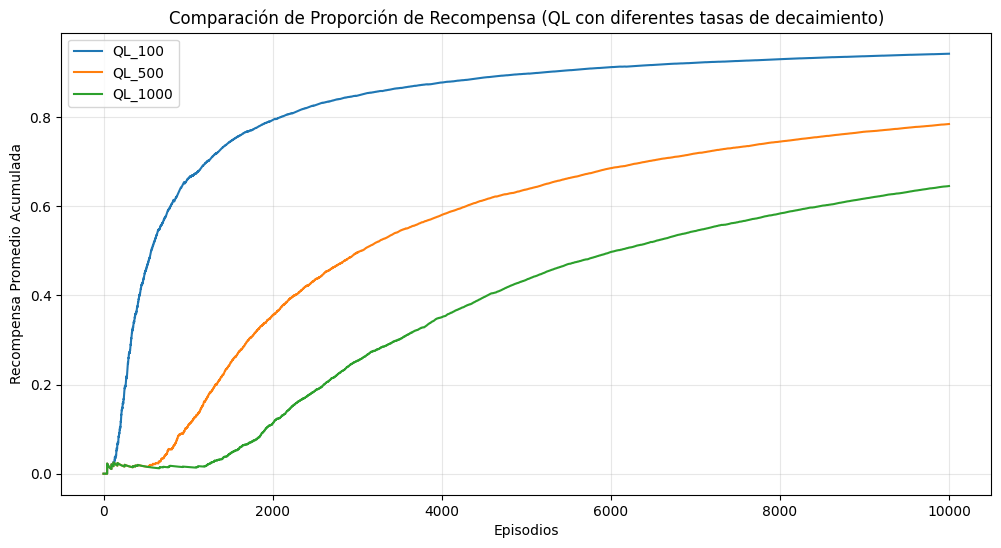

Rendimiento final (Promedio Acumulado) - QL con diferentes tasas de decaimiento:
QL_100: 0.9418
QL_500: 0.7842
QL_1000: 0.6451


In [40]:
#@title Proporción de aciertos por número de episodios
plot_rewards({"QL_100": {"stats": list_stats_ql_100}, "QL_500": {"stats": list_stats_ql_500}, "QL_1000": {"stats": list_stats_ql_1000}}, title_suffix="QL con diferentes tasas de decaimiento")

En la gráfica comparativa podemos observar el impacto de la tasa de decaimiento en el aprendizaje.
*   **Decaimiento rápido (100)**: La curva azul muestra un aprendizaje inicial más rápido en términos de explotación, pero puede estancarse antes si no ha explorado lo suficiente.
*   **Decaimiento lento (1000)**: La curva verde tarda más en subir, ya que el agente pasa más tiempo explorando (acciones aleatorias), lo que reduce el retorno promedio al principio. Sin embargo, a largo plazo, esta mayor exploración suele permitir encontrar una política más robusta y segura.
*   **Decaimiento medio (500)**: Ofrece un equilibrio entre ambos extremos.

En general, todas las configuraciones logran aprender, pero la tasa de 1000 parece ofrecer una convergencia final más sólida al haber explorado mejor el espacio de estados.

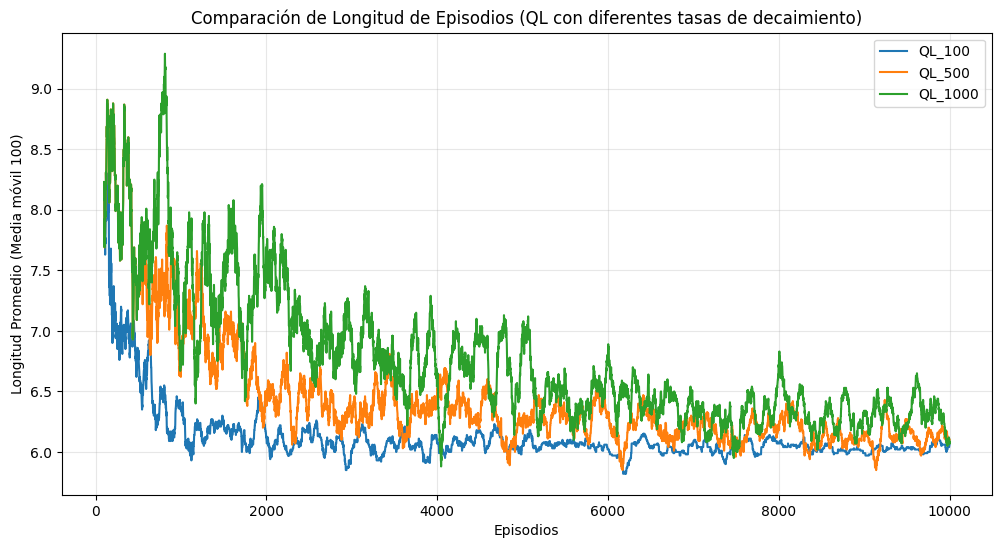

In [46]:
plot_lengths_comparison({"QL_100": all_episode_lengths_ql_100, "QL_500": all_episode_lengths_ql_500, "QL_1000": all_episode_lengths_ql_1000}, title_suffix="QL con diferentes tasas de decaimiento")

En cuanto a las longitudes de los episodios, observamos que las tres configuraciones muestran una tendencia clara a disminuir la longitud de los pasos hasta estabilizarse alrededor de 6 (el mínimo teórico para el camino óptimo en el mapa 4x4).

* **Decaimiento 100**: La longitud de los pasos disminuye más rápido al principio, ya que el agente deja de explorar antes. Además de mantener unos valores de pasos más estable.
* **Decaimiento 1000**: La longitud de los pasos se mantiene alta por más tiempo, lo cual es natural dado que el agente sigue explorando (haciendo movimientos aleatorios) durante más episodios. A medida que epsilon disminuye, la longitud se reduce hasta coincidir con las otras configuraciones.
* **Decaimiento 500**: La longitud de los pasos se mantiene en un punto medio entre usar decaimiento de 100 y de 1000.

Ahora vamos a mostrar el último frame del agente entrenado con la configuración de decaimiento 100, junto con la matriz Q aprendida.

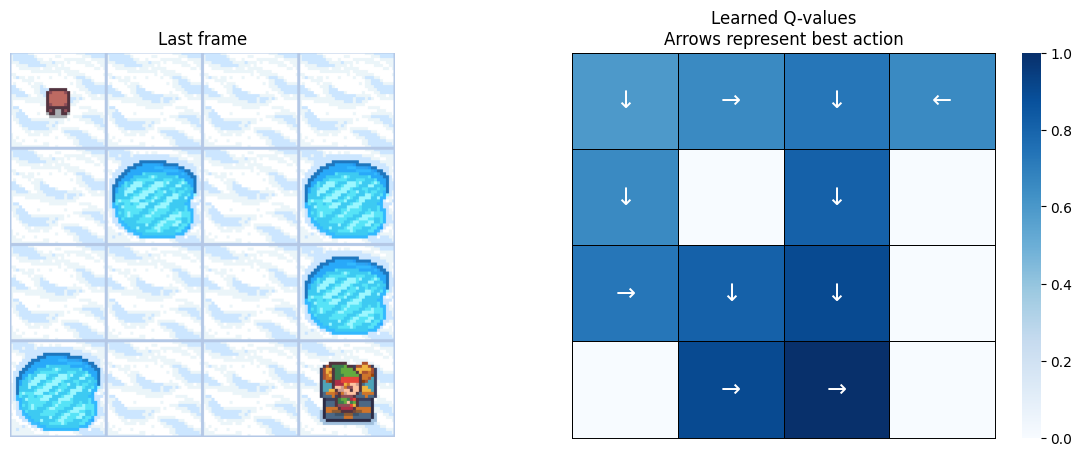

In [47]:
plot_q_values_map(agente_DT_QL_V4_100.Q, env4, 4)

En el último frame podemos ver como el agente logra llegar al objetivo correctamente.

Por otro lado, en la matriz de la derecha se ve cuales son esas mejores acciones para cada estado, donde si empezados desde el punto inicial, veremos que necesita 6 pasos para llegar al objtivo como veiamos en las gráficas anteriores.

Ahora vamos a generar un video de una ejecución utilizan esta matriz Q después del entrenamiento.

In [48]:
generar_video(env4, agente_DT_QL_V4_100.Q, video_folder=video_folder, num_episodes=1, seed=seed)
mostrar_video(get_latest_episode_video_file(video_folder))

c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\.venv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\Entornos_Complejos\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Grabación de episodios completada. Vídeos guardados en la carpeta './videos'


En el video podemos que sigue la ruta esperada viendo la mátriz Q generada anteriormente.

#### **3.2.3 Algoritmo de Doble Q-learning**

Ahora vamos a realizar el entrenamiento utilizando el algoritmo de **Doble Q-Learning**. Para ello, se han empleado los siguientes parámetros, comparando diferentes tasas de decaimiento:

- **Factor de descuento (alpha)**: 0.99
- **Epsilon Inicial**: 1.0
- **Epsilon Decay**: Activado ($\epsilon = \min(1.0, \frac{\text{decay\_rate}}{t+1})$)
- **Ratio de decay**: Tendremos tres ejecuciones para observar cómo afecta el aprendizaje:
    - ``100``: Decaimiento rápido.
    - ``500``: Decaimiento medio.
    - ``1000``: Decaimiento lento.

In [41]:
agente_DT_DQL_V4_100 = AgenteDT_Double_QL(env4, seed, discount_factor=0.99, epsilon=0.4, decay=True, num_episodes=10000, decay_rate=100.0)
list_stats_dql_100, all_episode_lengths_dql_100 = diferencia_temporal(env4, agente=agente_DT_DQL_V4_100, num_episodes=10000)

agente_DT_DQL_V4_500 = AgenteDT_Double_QL(env4, seed, discount_factor=0.99, epsilon=0.4, decay=True, num_episodes=10000, decay_rate=500.0)
list_stats_dql_500, all_episode_lengths_dql_500 = diferencia_temporal(env4, agente=agente_DT_DQL_V4_500, num_episodes=10000)

agente_DT_DQL_V4_1000 = AgenteDT_Double_QL(env4, seed, discount_factor=0.99, epsilon=0.4, decay=True, num_episodes=10000, decay_rate=1000.0)
list_stats_dql_1000, all_episode_lengths_dql_1000 = diferencia_temporal(env4, agente=agente_DT_DQL_V4_1000, num_episodes=10000)

 11%|█         | 1091/10000 [00:01<00:10, 879.37it/s]

Episode: 1000, Avg Return: 0.58, Epsilon: 0.100, Alpha: 0.172


 21%|██        | 2119/10000 [00:02<00:08, 924.00it/s]

Episode: 2000, Avg Return: 0.76, Epsilon: 0.050, Alpha: 0.066


 32%|███▏      | 3162/10000 [00:03<00:07, 939.59it/s]

...

 81%|████████  | 8105/10000 [00:10<00:02, 905.79it/s]

Episode: 8000, Avg Return: 0.59, Epsilon: 0.125, Alpha: 0.021


 92%|█████████▏| 9198/10000 [00:11<00:00, 935.66it/s]

Episode: 9000, Avg Return: 0.62, Epsilon: 0.111, Alpha: 0.018


100%|██████████| 10000/10000 [00:12<00:00, 781.36it/s]


Tras realizar el entrenamiento con los tres valores de decaimiento, obtenemos estos entrenamientos.
* **Decaimiento 100**: Para la primera versión con decaimiento 100, vuelve a ser el que más rápido aprende el camino, empezando desde 0.58 hasta 0.93, un poco por debajo que el algoritmo de Q-learning al tener ahora dos matrices Q.
* **Decaimiento 500**: Para la segunda versión, vemos que también aprende más lento que la anterior versión, aunque se mantiene un ritmo similar que el algoritmo de Q-learning.
* **Decaimiento 1000**: Finalmente, para la tercera versión, es la que más tarda en entrenar de nuevo, terminando con un return de 0.62. igual que el algoritmo de Q-learning.

Esto nos vuelve a desmostrar lo que vimos con Q-learning, aunque el uso de la doble Q no influye tanto al ser un problema simple.

Ahora vamos a ver su evolución gráficamente en la proporcion de la recompensa promedia y la media de longitud de episodios hasta llegar al final. 

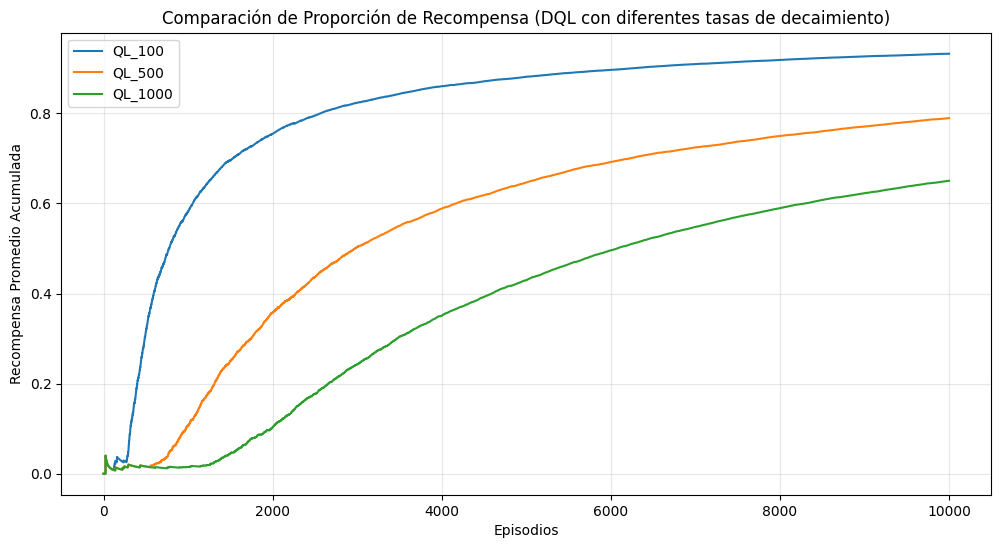

Rendimiento final (Promedio Acumulado) - DQL con diferentes tasas de decaimiento:
QL_100: 0.9324
QL_500: 0.7894
QL_1000: 0.6504


In [42]:
#@title Proporción de aciertos por número de episodios
plot_rewards({"QL_100": {"stats": list_stats_dql_100}, "QL_500": {"stats": list_stats_dql_500}, "QL_1000": {"stats": list_stats_dql_1000}}, title_suffix="DQL con diferentes tasas de decaimiento")

En la gráfica comparativa podemos observar el impacto de la tasa de decaimiento en el aprendizaje.
*   **Decaimiento rápido (100)**: La curva azul muestra un aprendizaje inicial más rápido en términos de explotación de la misma forma que pasaba en el 4x4.
*   **Decaimiento lento (1000)**: La curva verde tarda más en subir de manera similar a la del 4x4, aunque ahora se nota un mayor diferencia con el decaimiento de 100.
*   **Decaimiento medio (500)**: Ofrece de nuevo un punto intermedio entre los otros valores de decaimiento.

En general, todas las configuraciones logran aprender, pero la tasa de 100 parece ofrecer una solución más rápida, mientras que con 1000 puede dar lugar a buscar una más eficiente.

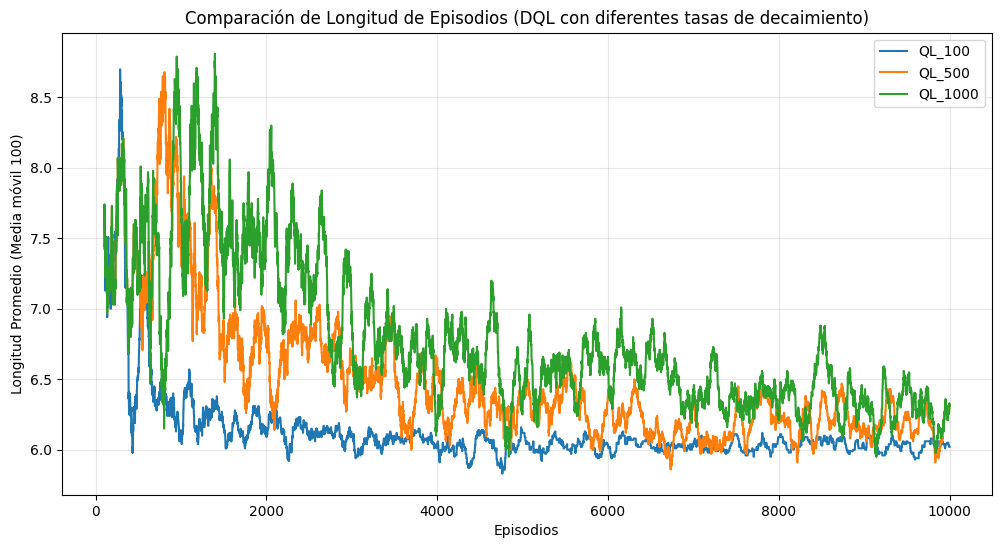

In [49]:
plot_lengths_comparison({"QL_100": all_episode_lengths_dql_100, "QL_500": all_episode_lengths_dql_500, "QL_1000": all_episode_lengths_dql_1000}, title_suffix="DQL con diferentes tasas de decaimiento")


En cuanto a las longitudes de los episodios, observamos que las tres configuraciones muestran una tendencia clara a disminuir la longitud de los pasos hasta estabilizarse alrededor de 6 (el mínimo teórico para el camino óptimo en el mapa 4x4).

* **Decaimiento 100**: La longitud de los pasos disminuye más rápido al principio, ya que el agente deja de explorar antes. Además, es el que mantiene un número de pasos más estable de primeras como lo hace el algoritmo de deep Q.
* **Decaimiento 1000**: La longitud de los pasos se mantiene alta por más tiempo y más variadad al tender más a esa exploración. A medida que epsilon disminuye, la longitud se reduce hasta coincidir con las otras configuraciones.
* **Decaimiento 500**: La longitud de los pasos se mantiene en un punto medio entre usar decaimiento de 100 y de 1000.

Ahora vamos a mostrar el último frame del agente entrenado con la configuración de decaimiento 100, junto con la matriz Q aprendida.

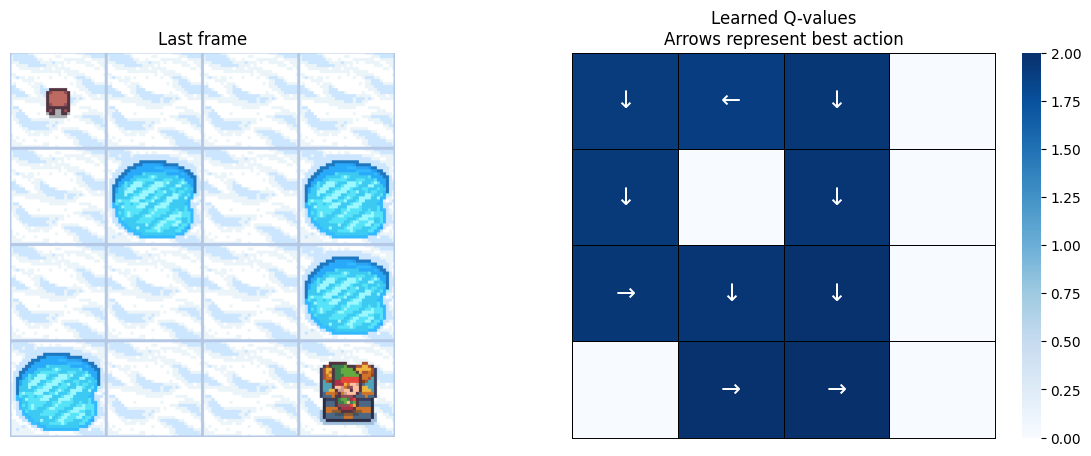

In [50]:
plot_q_values_map(agente_DT_DQL_V4_100.Q1+agente_DT_DQL_V4_100.Q2, env4, 4)

En el último frame podemos ver como el agente logra llegar al objetivo correctamente.

Por otro lado, en la matriz de la derecha se ve cuales son esas mejores acciones para cada estado, donde si empezados desde el punto inicial, veremos que necesita 6 pasos para llegar al objtivo como veiamos en las gráficas anteriores.

Ahora vamos a generar un video de una ejecución utilizan esta matriz Q después del entrenamiento.

In [51]:
generar_video(env4, agente_DT_DQL_V4_100.Q1+agente_DT_DQL_V4_100.Q2, video_folder=video_folder, num_episodes=1, seed=seed)
mostrar_video(get_latest_episode_video_file(video_folder))

c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\.venv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\Entornos_Complejos\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Grabación de episodios completada. Vídeos guardados en la carpeta './videos'


En el video vemos como sigue esa ruta de la matriz Q.

### **3.3 Experimentación en el escenario 8x8**

Para la experimentación en un escenario más complejo, al duplicar el tamaño del mapa de 4x4 a 8x8, se debe considerar que el número de pasos necesarios para alcanzar el objetivo aumenta significativamente. 

#### 3.3.1 Algoritmo de SARSA

In [18]:
# @title Aprendizaje
agente_DT_Sarsa_V8 = AgenteDT_Sarsa(env8, seed, discount_factor=0.9, epsilon=0.4, decay=True, num_episodes=30000, decay_rate=4000.0)
list_stats, all_episode_lengths = diferencia_temporal(env8, agente=agente_DT_Sarsa_V8, num_episodes=30000)

 10%|█         | 3067/30000 [00:05<00:42, 634.45it/s]

Episode: 3000, Avg Return: 0.00, Epsilon: 1.000, Alpha: 1.000


 21%|██        | 6153/30000 [00:10<00:32, 743.58it/s]

Episode: 6000, Avg Return: 0.01, Epsilon: 0.667, Alpha: 0.089


 30%|███       | 9117/30000 [00:13<00:22, 932.87it/s]

...

 81%|████████  | 24161/30000 [00:27<00:05, 1141.15it/s]

Episode: 24000, Avg Return: 0.56, Epsilon: 0.167, Alpha: 0.007


 91%|█████████ | 27194/30000 [00:29<00:02, 1341.03it/s]

Episode: 27000, Avg Return: 0.60, Epsilon: 0.148, Alpha: 0.006


100%|██████████| 30000/30000 [00:31<00:00, 951.24it/s] 


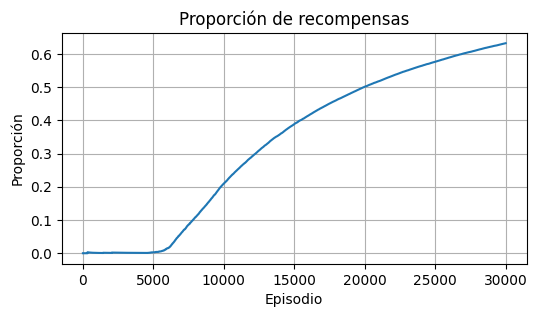

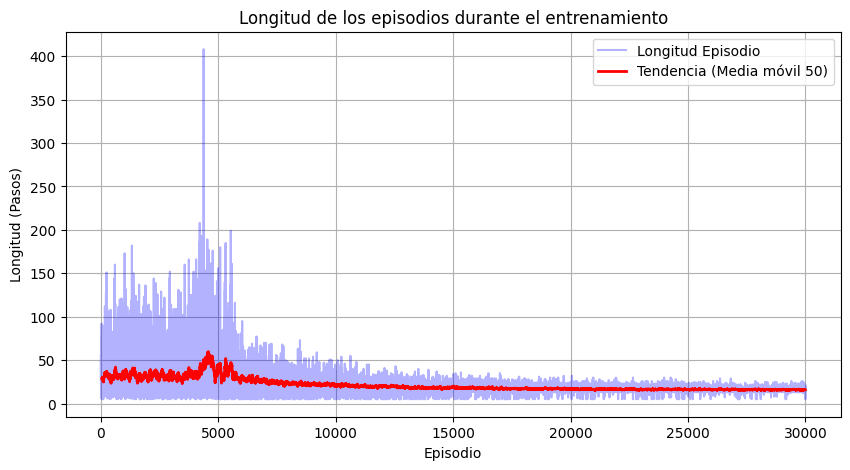

Máxima proporcion: 0.6322


In [19]:
#@title Proporción de aciertos por número de episodios

plot(list_stats)
plot_lengths(all_episode_lengths)
print(f"Máxima proporcion: {list_stats[-1]}")

Mostramos escenario

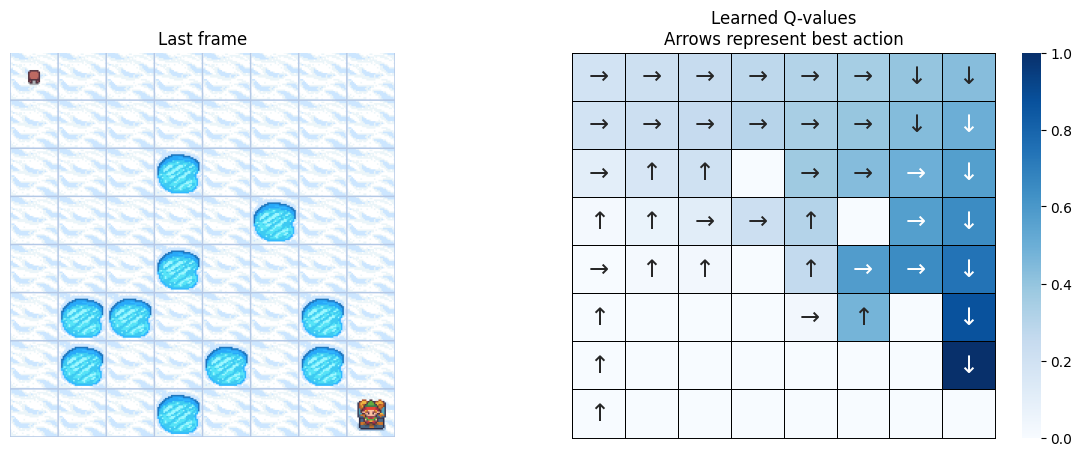

In [20]:
plot_q_values_map(agente_DT_Sarsa_V8.Q, env8, 8)

Mostramos video

In [21]:
generar_video(env8, agente_DT_Sarsa_V8.Q, video_folder=video_folder, num_episodes=1, seed=seed)
mostrar_video(get_latest_episode_video_file(video_folder))

c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\.venv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\Entornos_Complejos\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Grabación de episodios completada. Vídeos guardados en la carpeta './videos'


#### **3.3.2 Algoritmo de Q-Learning (8x8)**

Repetimos el experimento de **Q-Learning** para el mapa de 8x8. La complejidad aumenta cuadráticamente, por lo que la exploración se vuelve crítica.

- **Factor de descuento (alpha)**: 0.99
- **Epsilon Inicial**: 1.0
- **Epsilon Decay**: Activado
- **Ratio de decay**: Comparativa entre ``100``, ``500`` y ``1000``. Esperamos que tasas de decaimiento más lentas (como 1000) sean necesarias para cubrir el espacio de estados más grande.

In [68]:
# @title Aprendizaje
agente_DT_QL_V8_100 = AgenteDT_QL(env8, seed, discount_factor=0.9, epsilon=0.4, decay=True, num_episodes=10000, decay_rate=100.0)
list_stats_ql_v8_100, all_episode_lengths_ql_v8_100 = diferencia_temporal(env8, agente=agente_DT_QL_V8_100, num_episodes=10000)

agente_DT_QL_V8_500 = AgenteDT_QL(env8, seed, discount_factor=0.9, epsilon=0.4, decay=True, num_episodes=10000, decay_rate=500.0)
list_stats_ql_v8_500, all_episode_lengths_ql_v8_500 = diferencia_temporal(env8, agente=agente_DT_QL_V8_500, num_episodes=10000)

agente_DT_QL_V8_1000 = AgenteDT_QL(env8, seed, discount_factor=0.9, epsilon=0.4, decay=True, num_episodes=10000, decay_rate=1000.0)
list_stats_ql_v8_1000, all_episode_lengths_ql_v8_1000 = diferencia_temporal(env8, agente=agente_DT_QL_V8_1000, num_episodes=10000)

 11%|█▏        | 1126/10000 [00:02<00:14, 603.34it/s]

Episode: 1000, Avg Return: 0.47, Epsilon: 0.100, Alpha: 0.215


 21%|██        | 2107/10000 [00:04<00:11, 711.91it/s]

Episode: 2000, Avg Return: 0.70, Epsilon: 0.050, Alpha: 0.072


 31%|███▏      | 3132/10000 [00:05<00:09, 722.11it/s]

...

 81%|████████  | 8091/10000 [00:16<00:02, 681.80it/s]

Episode: 8000, Avg Return: 0.48, Epsilon: 0.125, Alpha: 0.026


 91%|█████████ | 9104/10000 [00:18<00:01, 690.67it/s]

Episode: 9000, Avg Return: 0.52, Epsilon: 0.111, Alpha: 0.021


100%|██████████| 10000/10000 [00:19<00:00, 509.53it/s]


Tras realizar el entrenamiento con los tres valores de decaimiento, obtenemos estos entrenamientos.
* **Decaimiento 100**: Para la primera versión con decaimiento 100, vemos de nuevo que aprende muy rápido el camino solución al tener un valor de return medio de 0.47 desde el episodio 1000, llegando a 0.91 al final del entrenamiento. Sus valores más bajos respecto al otro Q-Learning se debe a que ahora contamos con un problema más complejo, por lo que tarda más en encontrar dicho camino.
* **Decaimiento 500**: Para la segunda versión, vemos que ya también empieza a tardar más en aprender el camino solución al querer explorar más respecto al anterior, teniendo que necesitar 3000 episodios para llegar a un return medio de 0.49, terminado con 0.78.
* **Decaimiento 1000**: Finalmente, para la tercera versión, es la que más tarda en entrenar, terminando con un return de 0.52.

Ahora vamos a ver su evolución gráficamente en la proporcion de la recompensa promedia y la media de longitud de episodios hasta llegar al final. 

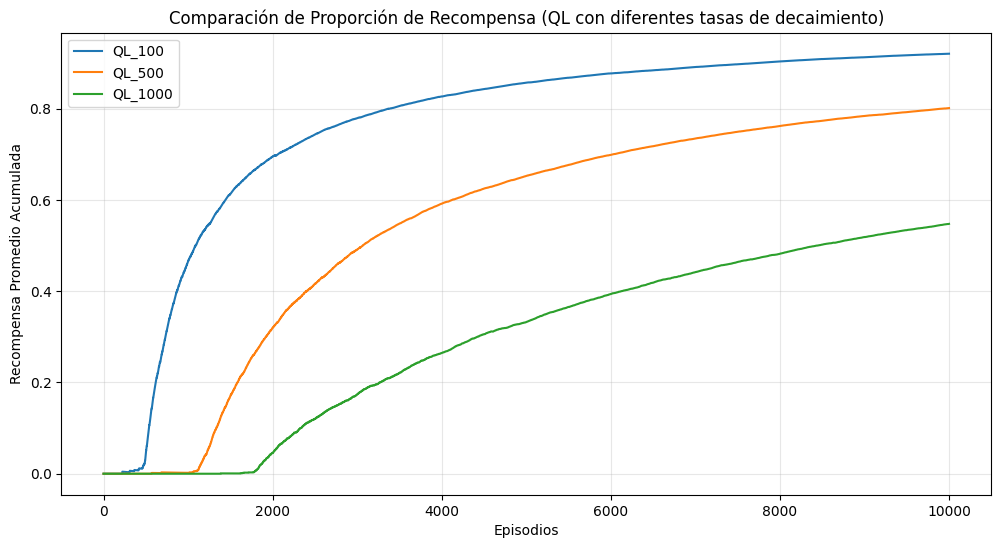

Rendimiento final (Promedio Acumulado) - QL con diferentes tasas de decaimiento:
QL_100: 0.9203
QL_500: 0.8012
QL_1000: 0.5475


In [55]:
#@title Proporción de aciertos por número de episodios
#@title Proporción de aciertos por número de episodios
plot_rewards({"QL_100": {"stats": list_stats_ql_v8_100}, "QL_500": {"stats": list_stats_ql_v8_500}, "QL_1000": {"stats": list_stats_ql_v8_1000}}, title_suffix="QL con diferentes tasas de decaimiento")

En la gráfica comparativa podemos observar el impacto de la tasa de decaimiento en el aprendizaje.
*   **Decaimiento rápido (100)**: La curva azul sigue mostrando un aprendizaje inicial más rápido en términos de explotación, explotando el camino solución el primero de todos.
*   **Decaimiento lento (1000)**: La curva verde tarda más en subir, ya que el agente pasa más tiempo explorando (acciones aleatorias), lo que reduce el retorno promedio al principio.
*   **Decaimiento medio (500)**: Ofrece un equilibrio entre ambos extremos.

En general, se obtiene una gráfica similar a la obtenida en el 4x4.

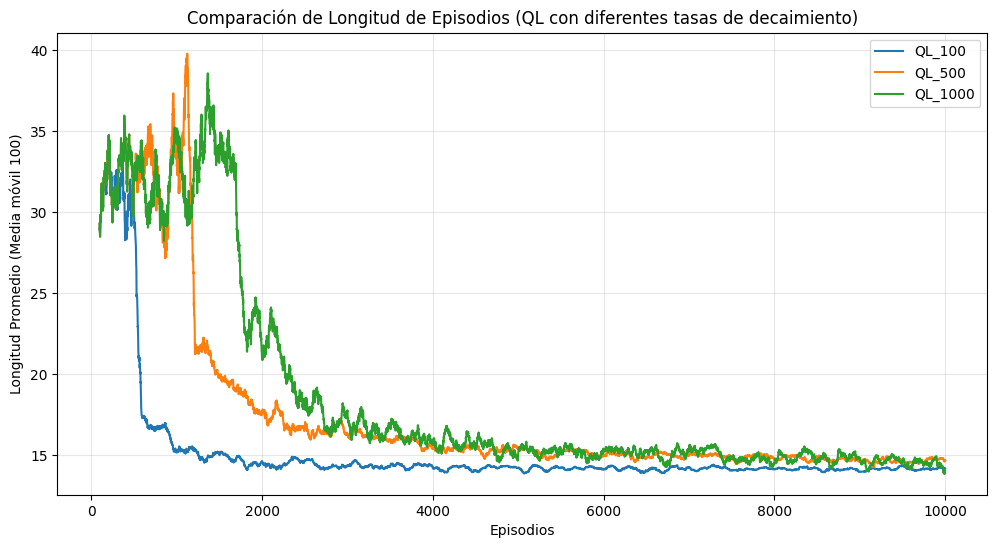

In [58]:
plot_lengths_comparison({"QL_100": all_episode_lengths_ql_v8_100, "QL_500": all_episode_lengths_ql_v8_500, "QL_1000": all_episode_lengths_ql_v8_1000}, title_suffix="QL con diferentes tasas de decaimiento")

En el escenario 8x8 con Double Q-Learning:

* **Decaimiento 100**: La evolución de la longitud de pasos empieza realizando el mismo número de pasos que el resto de decaimientos, pero luego, al ser el primero que explota el camino solución, baja sus pasos por episodios a los requeridos para llegar a la solución.
* **Decaimiento 1000**: Su evolución es la que más tarda en empezar a encontrar episodios donde encuentra algo de recompensa, por eso que tarde más en bajar de los 30-35 pasos. Sin embargo, lo sigue haciendo rápido y la explotación del camino solución la realiza más rápidamente que en el 4x4.
* **Decaimiento 500**: Su inicio es similar a la versión de 1000, sin embargo explota más rápidamente el camino solución. Además, termina temiendo una media de pasos más similar a la versión de 1000.

Ahora vamos a ver la diferencia entre las matrices Q de la versión con decaimiento de 100.

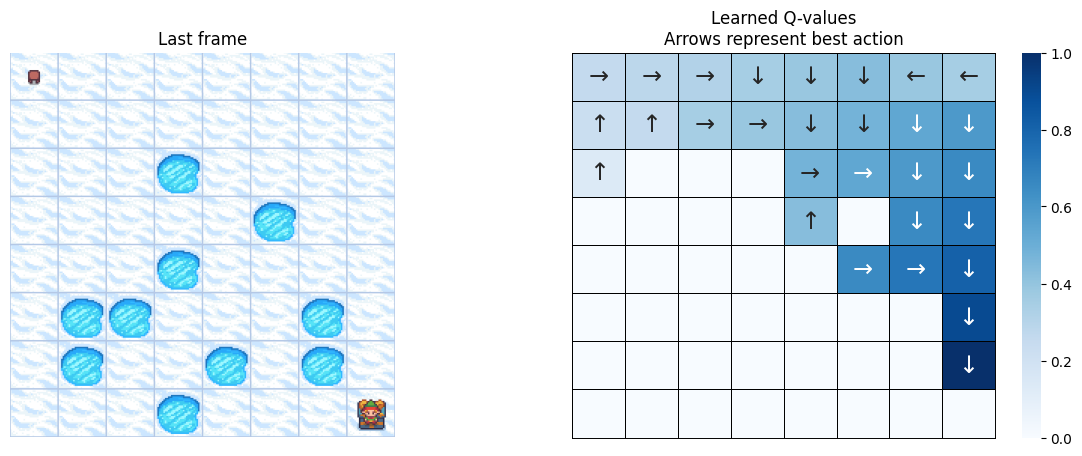

In [59]:
plot_q_values_map(agente_DT_QL_V8_100.Q, env8, 8)

Observamos la política del agente en el escenario 8x8. El mapa de calor de valores Q es más difuso inicialmente, ya que muchos estados menos frecuentados tienen estimaciones más pobres. Sin embargo, la ruta crítica hacia la meta debe tener valores claramente más altos que los agujeros circundantes.

In [60]:
generar_video(env8, agente_DT_QL_V8_100.Q, video_folder=video_folder, num_episodes=1, seed=seed)
mostrar_video(get_latest_episode_video_file(video_folder))

c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\.venv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\Entornos_Complejos\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Grabación de episodios completada. Vídeos guardados en la carpeta './videos'


En el video observamos el recorrido del agente. Al ser un mapa 8x8, la trayectoria es más larga y compleja. La clave será observar si el agente elige acciones seguras que evitan los agujeros, lo cual es más crítico aquí que en el mapa 4x4.

#### **3.3.3 Algoritmo Double Q-Learning (8x8)**

Ahora evaluaremos **Double Q-Learning** en el escenario 8x8. Este entorno es propenso a valores Q sobreestimados iniciales, por lo que Double Q-Learning puede evitar oscilaciones innecesarias durante la exploración de caminos.

- **Factor de descuento (alpha)**: 0.99
- **Epsilon Inicial**: 0.4
- **Epsilon Decay**: Activado
- **Ratio de decay**: Comparativa entre ``100``, ``500`` y ``1000``. Esperamos una mejora en la estabilidad con la tasa de decaimiento lenta (1000).

In [61]:
agente_DT_DQL_V8_100 = AgenteDT_Double_QL(env8, seed, discount_factor=0.99, epsilon=0.4, decay=True, num_episodes=10000, decay_rate=100.0)
list_stats_dql_v8_100, all_episode_lengths_dql_v8_100 = diferencia_temporal(env8, agente=agente_DT_DQL_V8_100, num_episodes=10000)

agente_DT_DQL_V8_500 = AgenteDT_Double_QL(env8, seed, discount_factor=0.99, epsilon=0.4, decay=True, num_episodes=10000, decay_rate=500.0)
list_stats_dql_v8_500, all_episode_lengths_dql_v8_500 = diferencia_temporal(env8, agente=agente_DT_DQL_V8_500, num_episodes=10000)

agente_DT_DQL_V8_1000 = AgenteDT_Double_QL(env8, seed, discount_factor=0.99, epsilon=0.4, decay=True, num_episodes=10000, decay_rate=1000.0)
list_stats_dql_v8_1000, all_episode_lengths_dql_v8_1000 = diferencia_temporal(env8, agente=agente_DT_DQL_V8_1000, num_episodes=10000)

 10%|█         | 1034/10000 [00:03<00:27, 329.67it/s]

Episode: 1000, Avg Return: 0.00, Epsilon: 0.100, Alpha: 1.000


 20%|██        | 2025/10000 [00:07<00:26, 300.62it/s]

Episode: 2000, Avg Return: 0.00, Epsilon: 0.050, Alpha: 0.481


 31%|███       | 3076/10000 [00:10<00:19, 353.17it/s]

...

 80%|████████  | 8044/10000 [00:19<00:03, 578.66it/s]

Episode: 8000, Avg Return: 0.59, Epsilon: 0.125, Alpha: 0.021


 91%|█████████ | 9113/10000 [00:20<00:01, 652.56it/s]

Episode: 9000, Avg Return: 0.63, Epsilon: 0.111, Alpha: 0.018


100%|██████████| 10000/10000 [00:22<00:00, 446.25it/s]


Tras realizar el entrenamiento con los tres valores de decaimiento, obtenemos estos entrenamientos.
* **Decaimiento 100**: Para la primera versión con decaimiento 100, ahora nos encontramos con que los primeros 5000 episodios no logra encontrar el camino solución al tener un bajo valor de epsilon. Sin embargo, una vez lo encuentra, el valor de return medio llega a 0.38.
* **Decaimiento 500**: Para la segunda versión, se obtiene un ritmo similar a anteriores entrenamientos, llegando a un return de 0.69. 
* **Decaimiento 1000**: Finalmente, para la tercera versión, es la que más tarda en entrenar, terminando con un return de 0.52.

Ahora vamos a ver su evolución gráficamente en la proporcion de la recompensa promedia y la media de longitud de episodios hasta llegar al final. 

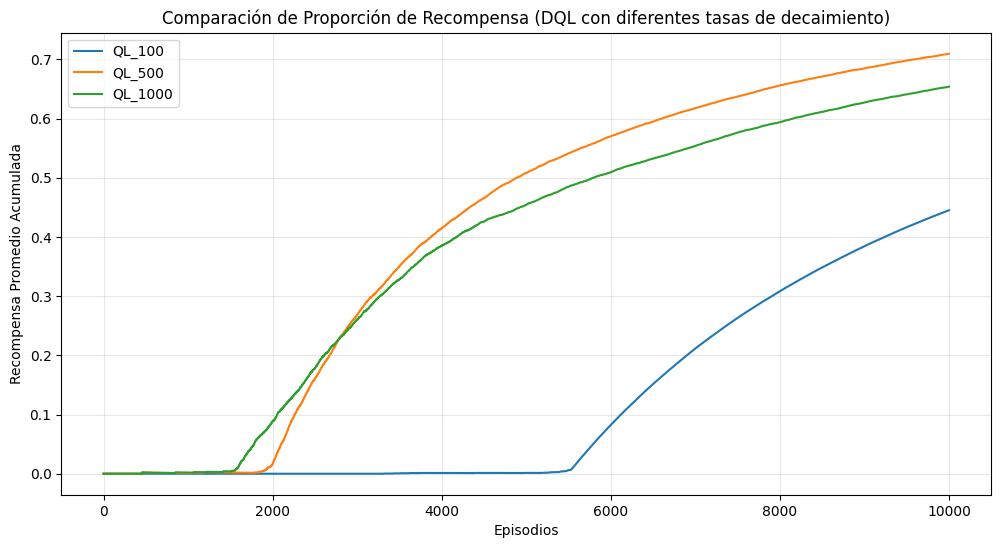

Rendimiento final (Promedio Acumulado) - DQL con diferentes tasas de decaimiento:
QL_100: 0.4452
QL_500: 0.7097
QL_1000: 0.6541


In [62]:
#@title Proporción de aciertos por número de episodios
plot_rewards({"QL_100": {"stats": list_stats_dql_v8_100}, "QL_500": {"stats": list_stats_dql_v8_500}, "QL_1000": {"stats": list_stats_dql_v8_1000}}, title_suffix="DQL con diferentes tasas de decaimiento")

En el escenario 8x8 con Double Q-Learning:

* **Decaimiento 1000**: Ahora nos encontramos que la versión de 1000 es la que más valor de recompensa promedio obtiene
* **Decaimiento 100**: Su evolución es la que más tarda en empezar a encontrar episodios donde encuentra algo de recompensa, por eso que tarde más en bajar de los 30-35 pasos. Sin embargo, una vez encuentra una solución, es la que más la explota, dando lugar a que sea consistente en el número de pasos.
* **Decaimiento 500**: Su inicio es similar a la versión de 1000, sin embargo explota más rápidamente el camino solución. Además, termina temiendo una media de pasos más similar a la versión de 100.

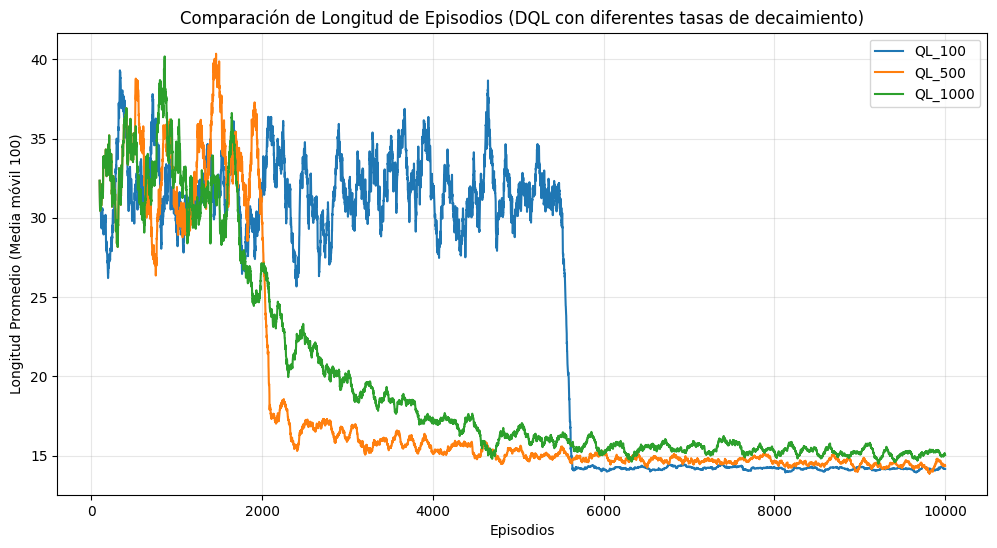

In [63]:
plot_lengths_comparison({"QL_100": all_episode_lengths_dql_v8_100, "QL_500": all_episode_lengths_dql_v8_500, "QL_1000": all_episode_lengths_dql_v8_1000}, title_suffix="DQL con diferentes tasas de decaimiento")


En el escenario 8x8 con Double Q-Learning:

* **Decaimiento 1000**: La evolución de la longitud de pasos empieza realizando el mismo número de pasos que el resto de decaimientos, pero luego va decreciendo un poco más lentamente que la versión de 500 debido a que su epsilon va bajando más lento, haciendo que explore más. A la larga, es la que realiza uno o dos pasos más que el resto.
* **Decaimiento 100**: Su evolución es la que más tarda en empezar a encontrar episodios donde encuentra algo de recompensa, por eso que tarde más en bajar de los 30-35 pasos. Sin embargo, una vez encuentra una solución, es la que más la explota, dando lugar a que sea consistente en el número de pasos.
* **Decaimiento 500**: Su inicio es similar a la versión de 1000, sin embargo explota más rápidamente el camino solución. Además, termina temiendo una media de pasos más similar a la versión de 100.

Ahora vamos a ver la diferencia entre las matrices Q de la versión con decaimiento de 100 y de 1000 y analizarlas.

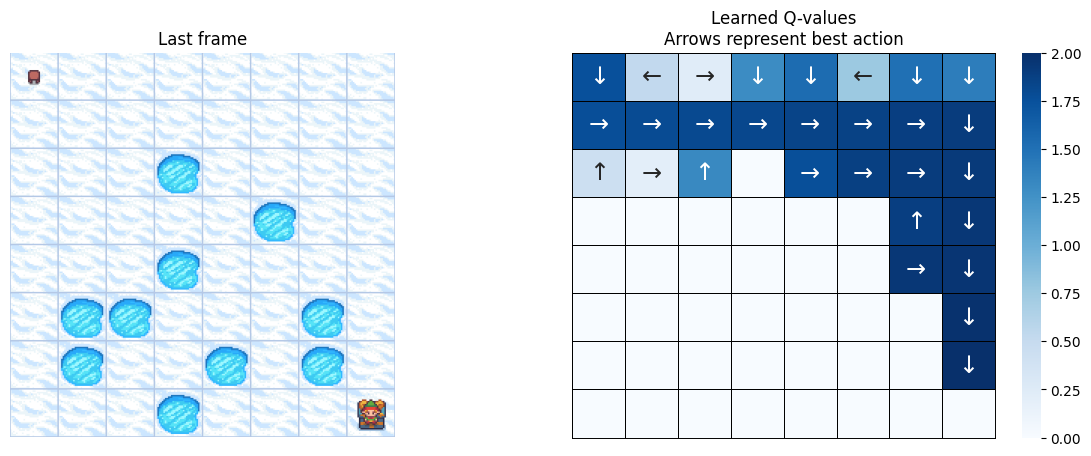

In [65]:
plot_q_values_map(agente_DT_DQL_V8_100.Q1+agente_DT_DQL_V8_100.Q2, env8, 8)

La versión de decaimiento de 100 se ve como explora menos estados al no haber una acción elegida, además de que los estados que forman el camino solución son los que más intesidad tienen.

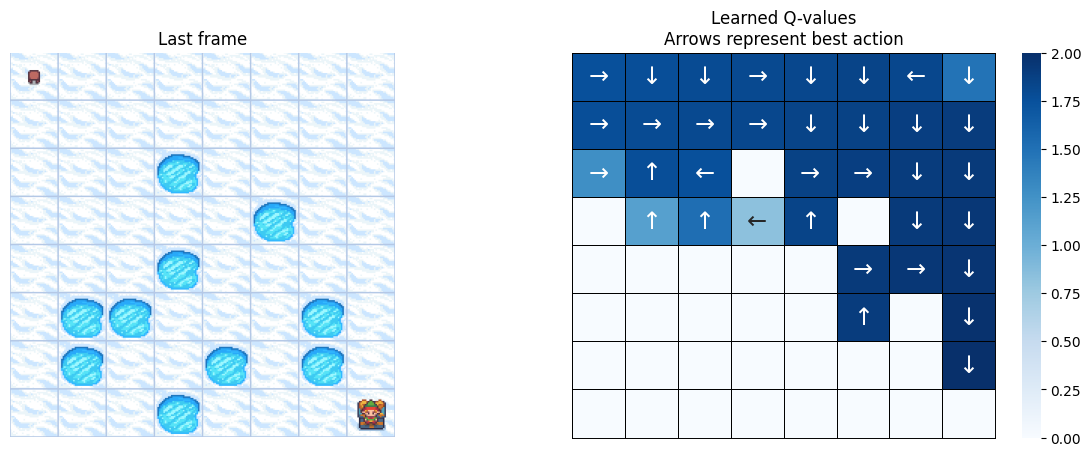

In [66]:
plot_q_values_map(agente_DT_DQL_V8_500.Q1+agente_DT_DQL_V8_500.Q2, env8, 8)

Comparando con la matriz de valores Q para una versión con **decaimiento más lento** (como 500 o 1000), deberíamos ver una mayor dispersión de estados visitados y valores aprendidos, reflejando una exploración más amplia del entorno.

A continuación, generamos un video con la trayectoria del mejor agente (probablemente la versión de decaimiento 100) para verificar visualmente que evita los agujeros y alcanza la meta eficientemente.

In [67]:
generar_video(env8, agente_DT_DQL_V8_100.Q1+agente_DT_DQL_V8_100.Q2, video_folder=video_folder, num_episodes=1, seed=seed)
mostrar_video(get_latest_episode_video_file(video_folder))

c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\.venv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\Entornos_Complejos\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Grabación de episodios completada. Vídeos guardados en la carpeta './videos'


En el video se muestra la política resultante. Al ser el mapa 8x8, la solución óptima es más larga y requiere que el agente navegue con precisión para evitar una mayor probabilidad de error. Double Q-Learning suele encontrar una ruta más robusta, aunque a veces toma más decisiones conservadoras para evitar el abismo.

## **4. Análisis y Estudios Futuros**

### **4.1 Análisis de Resultados**

- En los dos entornos (4x4 y 8x8), el agente comienza con un conocimiento muy limitado, pero gradualmente mejora su desempeño a medida que avanza en los episodios. Este comportamiento se puede observar en el gráfico de la proporción de recompensas, que aumenta con el tiempo.
- En el entorno 4x4, la máxima proporción de éxito alcanzada fue 0.522, mientras que en el entorno 8x8, la máxima alcanzada fue 0.914. Esto refleja que el agente aprendió a optimizar su estrategia en un entorno más complejo.
- La política óptima obtenida muestra las acciones recomendadas por el agente en cada estado del entorno. En el entorno 8x8, la política es más compleja debido a la mayor cantidad de estados y la dificultad del entorno.

### **4.2 Propuestas para Estudios Futuros**

1. **Evaluar con Otros Entornos**: Sería interesante aplicar este algoritmo a otros entornos más complejos de `gym`, como "Taxi-v3" o "MountainCar", para analizar cómo se comporta el agente en situaciones con dinámicas más complicadas.
   
2. **Optimización del Decaimiento de Epsilon**: Aunque se utilizó un decaimiento de epsilon en el segundo experimento, se podría investigar la efectividad de diferentes tasas de decaimiento o incluso explorar algoritmos como `Q-learning` para comparar su desempeño. Graficamente se trataría de mostrar la curva de la tasa de aciertos para distintas funciones de decaimientos

3. **Análisis del Impacto de los descuentos en las Recompensas**: El estudio se ha hecho para $\gamma = 1$; pero no se ha probado qué pasa cuando  $0 \leq \gamma < 1$. Se trataría de estudiar la curva para distintos valores de $\gamma$

4. **Nuevas gráficas**: Aquí solo se ha usado la proporción de aciertos, pero sería interesante qué relación entre dicha tasa y las tamaños de los episodios.

4. **Ampliación del Algoritmo**: Explorar otros enfoques de Monte Carlo o incluso combinar Monte Carlo con otros algoritmos de aprendizaje por refuerzo, como el Deep Q-Network (DQN), podría mejorar aún más los resultados en entornos más complejos.
